In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


In [10]:
processed_dir = Path("../data/processed")
figures_dir = Path("../figures")
models_dir = Path("../models")

figures_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)


In [11]:
heart_train = pd.read_csv(processed_dir / "heart_train.csv")
heart_test = pd.read_csv(processed_dir / "heart_test.csv")

heart_train.head()


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,62,male,va long beach,asymptomatic,135.0,297.0,0,normal,130.0,1,1.0,flat,0,normal,1
1,53,female,cleveland,non-anginal,128.0,216.0,0,lv hypertrophy,115.0,0,0.0,upsloping,0,normal,0
2,51,male,switzerland,asymptomatic,130.0,0.0,0,st-t abnormality,163.0,0,0.0,flat,0,reversable defect,1
3,48,female,hungary,atypical angina,120.0,284.0,0,normal,120.0,0,0.0,flat,0,normal,0
4,56,male,hungary,atypical angina,130.0,184.0,0,normal,100.0,0,0.0,flat,0,normal,0


In [12]:
numerical_features = ["age", "trestbps", "chol", "thalch", "oldpeak"]
categorical_features = ["sex", "dataset", "cp", "restecg", "slope", "thal"]
binary_discrete_features = ["fbs", "exang", "ca"]
target_column = "target"


In [13]:
target_counts = heart_train[target_column].value_counts().sort_index()
target_counts


target
0    329
1    407
Name: count, dtype: int64

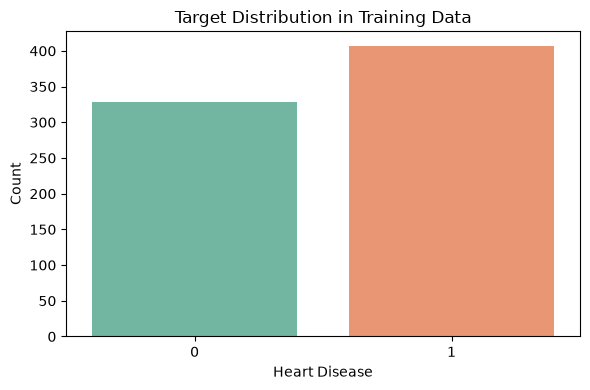

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=heart_train, x=target_column, hue=target_column, palette="Set2", legend=False)
plt.title("Target Distribution in Training Data")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(figures_dir / "target_distribution.png", dpi=300)
plt.show()


In [15]:
heart_train[numerical_features].describe().T


,count,mean,std,min,25%,50%,75%,max
age,736.0,53.427989,9.447613,28.0,47.0,54.0,60.0,77.0
trestbps,736.0,131.762228,18.272666,0.0,120.0,130.0,140.0,200.0
chol,736.0,198.601902,108.450536,0.0,177.0,223.0,266.0,564.0
thalch,736.0,137.418478,25.080743,60.0,120.0,140.0,155.0,194.0
oldpeak,736.0,0.831929,1.026545,-2.6,0.0,0.5,1.5,5.6


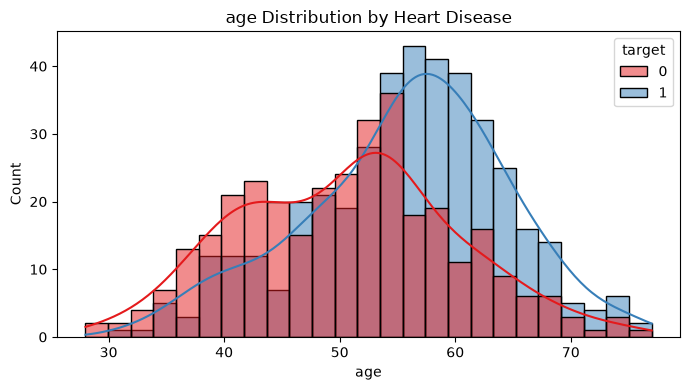

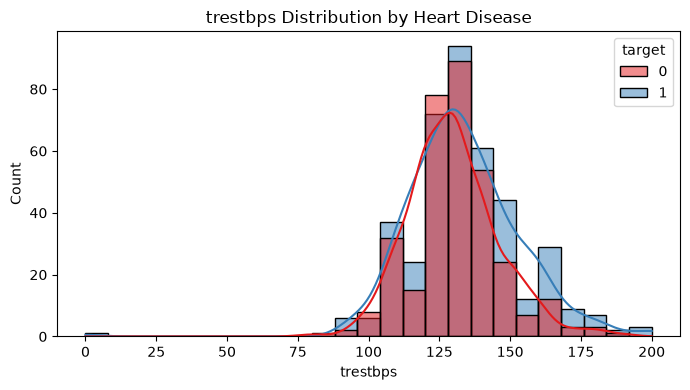

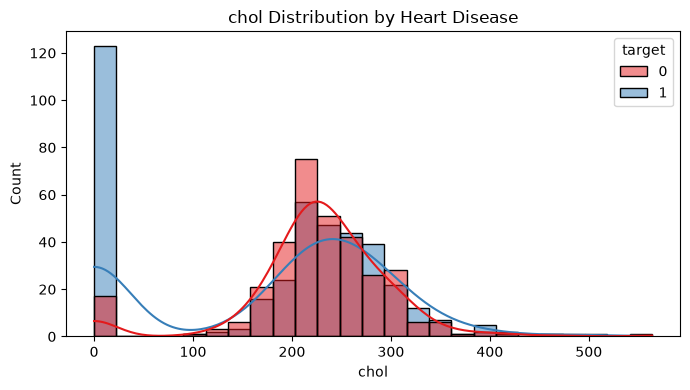

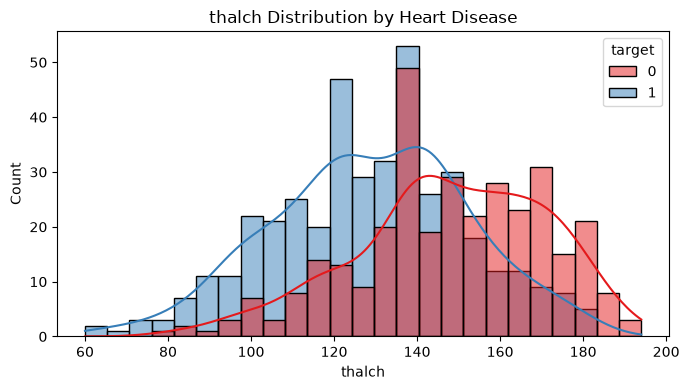

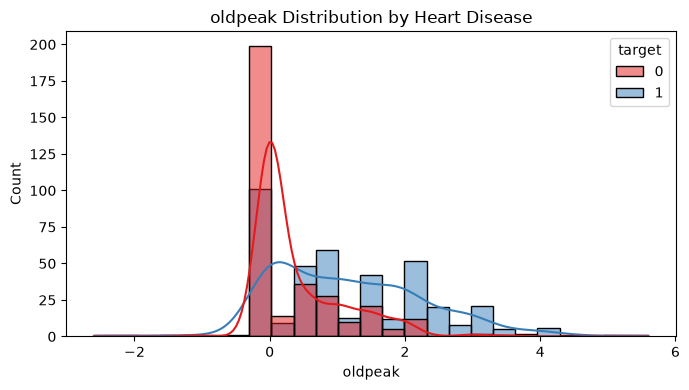

In [16]:
for column in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=heart_train, x=column, hue=target_column, kde=True, bins=25, palette="Set1")
    plt.title(f"{column} Distribution by Heart Disease")
    plt.tight_layout()
    plt.savefig(figures_dir / f"{column}_distribution.png", dpi=300)
    plt.show()


In [17]:
heart_train[categorical_features].describe().T


,count,unique,top,freq
sex,736,2,male,583
dataset,736,4,hungary,245
cp,736,4,asymptomatic,390
restecg,736,3,normal,451
slope,736,3,flat,534
thal,736,3,normal,539


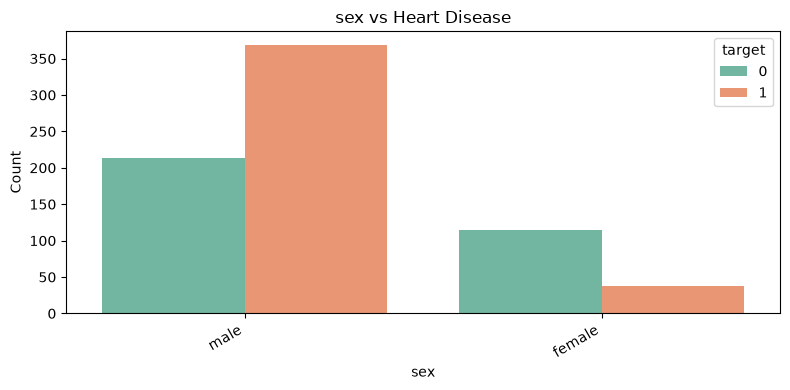

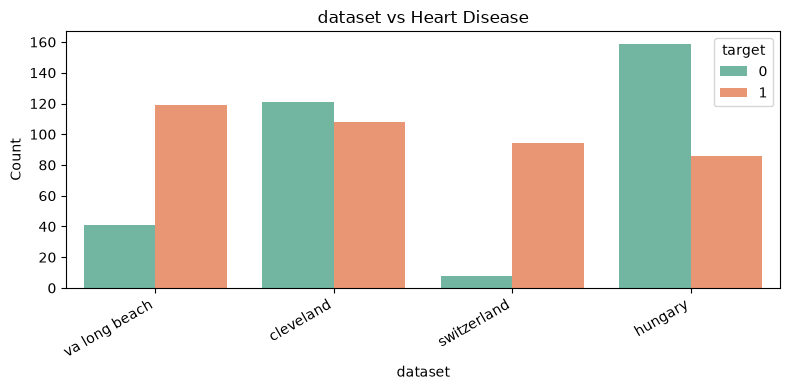

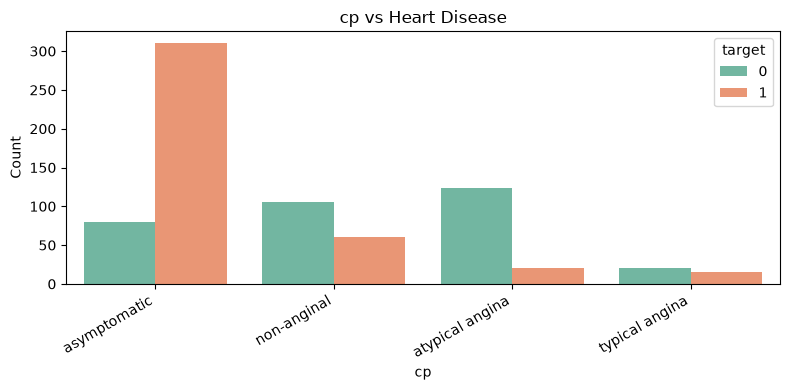

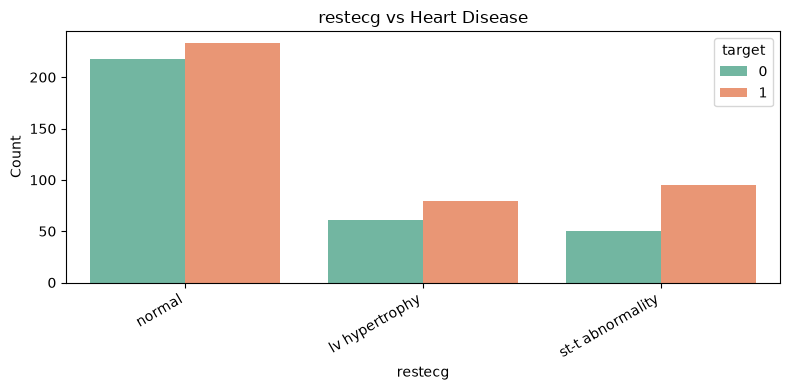

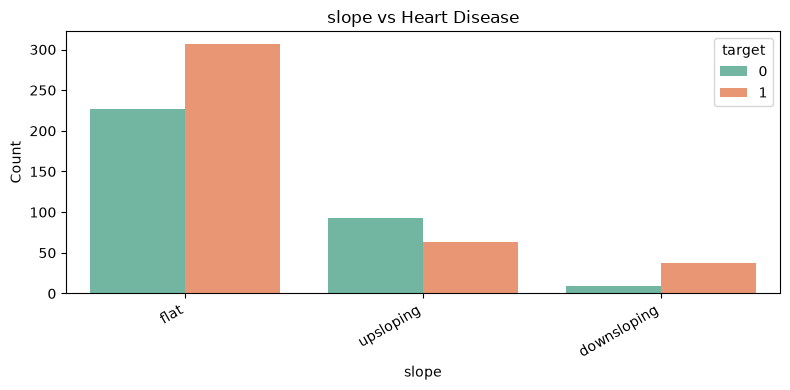

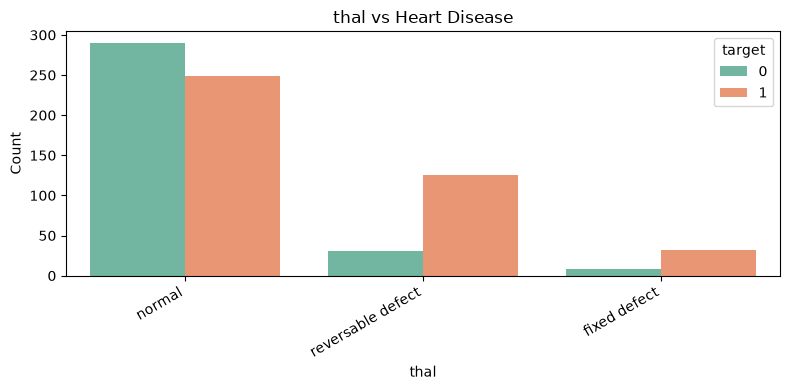

In [18]:
for column in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=heart_train, x=column, hue=target_column, palette="Set2")
    plt.title(f"{column} vs Heart Disease")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(figures_dir / f"{column}_target.png", dpi=300)
    plt.show()


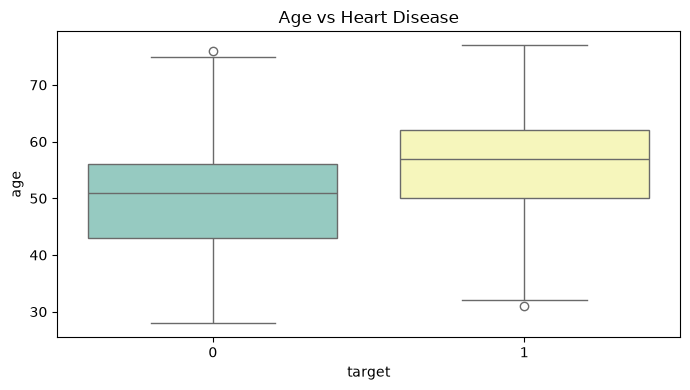

In [19]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=heart_train, x=target_column, y="age", hue=target_column, palette="Set3", legend=False)
plt.title("Age vs Heart Disease")
plt.tight_layout()
plt.savefig(figures_dir / "age_vs_heart_disease.png", dpi=300)
plt.show()


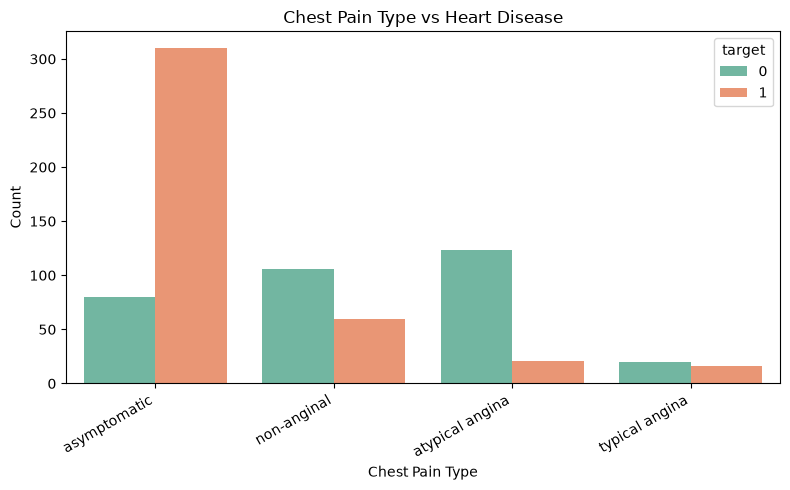

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=heart_train, x="cp", hue=target_column, palette="Set2")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "chest_pain_target.png", dpi=300)
plt.show()


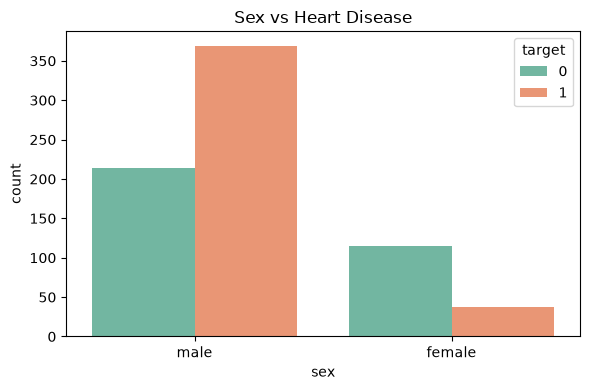

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=heart_train, x="sex", hue=target_column, palette="Set2")
plt.title("Sex vs Heart Disease")
plt.tight_layout()
plt.savefig(figures_dir / "sex_target.png", dpi=300)
plt.show()


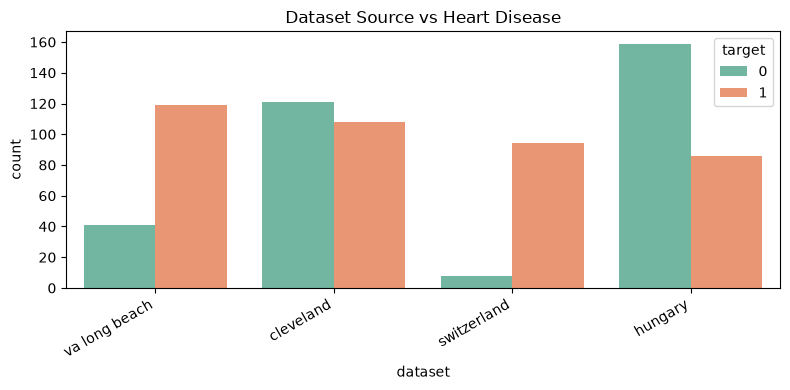

In [22]:
plt.figure(figsize=(8, 4))
sns.countplot(data=heart_train, x="dataset", hue=target_column, palette="Set2")
plt.title("Dataset Source vs Heart Disease")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "dataset_target.png", dpi=300)
plt.show()


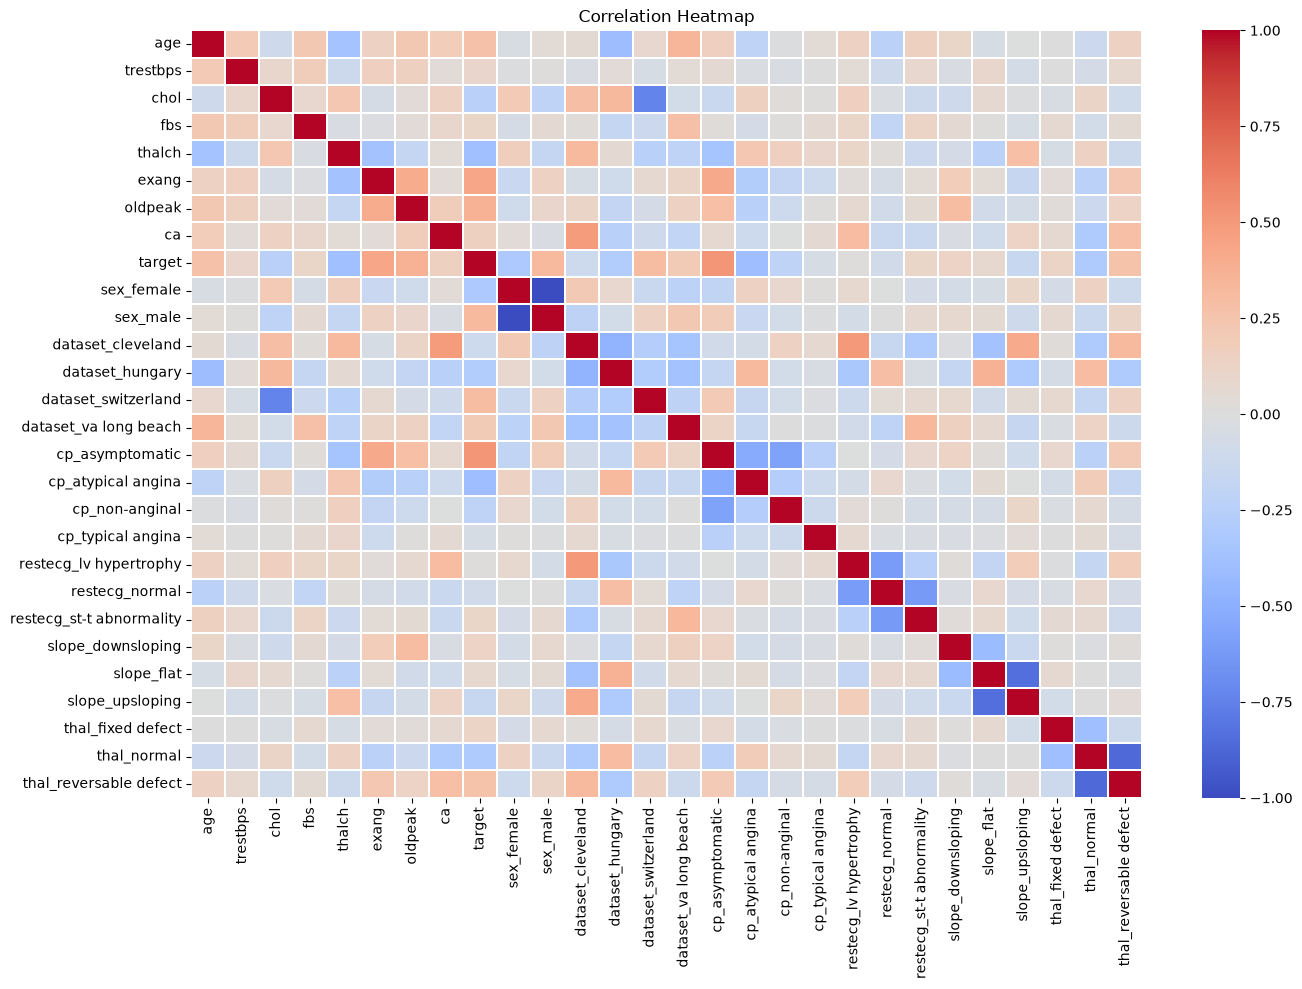

In [23]:
eda_encoded = pd.get_dummies(heart_train, columns=categorical_features, drop_first=False)
correlation_matrix = eda_encoded.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(figures_dir / "correlation_heatmap.png", dpi=300)
plt.show()


In [24]:
X_train = heart_train.drop(columns=[target_column])
y_train = heart_train[target_column]
X_test = heart_test.drop(columns=[target_column])
y_test = heart_test[target_column]


In [25]:
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("bin", "passthrough", binary_discrete_features)
    ]
)


In [26]:
X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)


In [27]:
feature_names = preprocessing_pipeline.get_feature_names_out()
feature_names = [name.split("__", 1)[1] for name in feature_names]

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

X_train_processed[target_column] = y_train.reset_index(drop=True)
X_train_processed["split"] = "train"

X_test_processed[target_column] = y_test.reset_index(drop=True)
X_test_processed["split"] = "test"

heart_final = pd.concat([X_train_processed, X_test_processed], ignore_index=True)
heart_final.head()


,age,trestbps,chol,thalch,oldpeak,sex_female,sex_male,dataset_cleveland,dataset_hungary,dataset_switzerland,...,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect,fbs,exang,ca,target,split
0,0.907937,0.177313,0.907926,-0.295985,0.163836,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,train
1,-0.045332,-0.206034,0.160533,-0.894460,-0.810968,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0,train
2,-0.257170,-0.096506,-1.832512,1.020660,-0.810968,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,train
3,-0.574926,-0.644144,0.787974,-0.694968,-0.810968,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,train
4,0.272424,-0.096506,-0.134733,-1.492935,-0.810968,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,train


In [28]:
rf_preview = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_preview.fit(X_train_processed.drop(columns=[target_column, "split"]), X_train_processed[target_column])

feature_importance = pd.DataFrame({
    "feature": X_train_processed.drop(columns=[target_column, "split"]).columns,
    "importance": rf_preview.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)


,feature,importance
2,chol,0.107590
11,cp_asymptomatic,0.105516
4,oldpeak,0.102493
3,thalch,0.101978
0,age,0.094268
1,trestbps,0.065811
25,exang,0.065540
12,cp_atypical angina,0.048455
6,sex_male,0.028959
22,thal_normal,0.028598


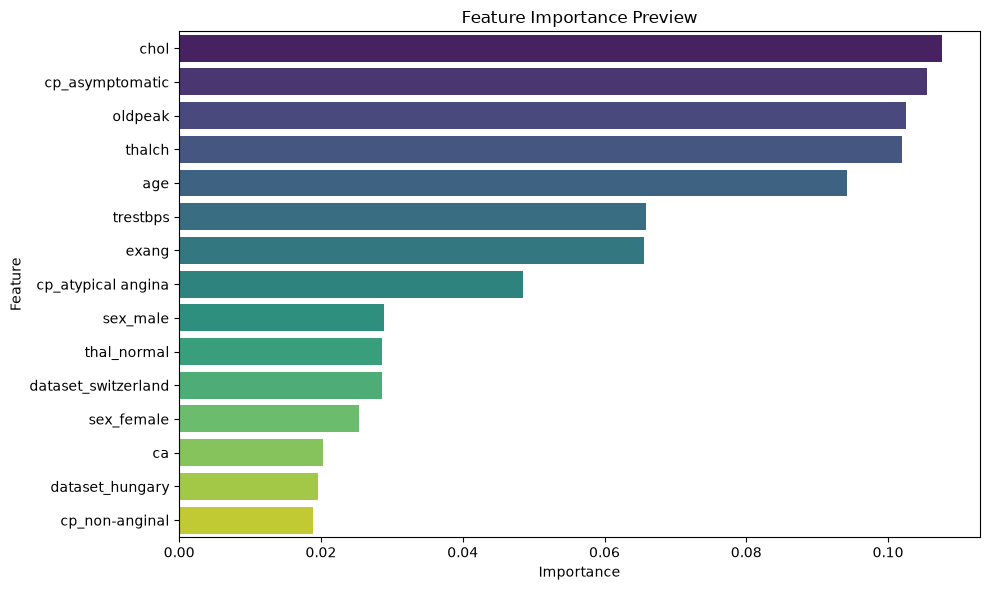

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature", palette="viridis", hue="feature", legend=False)
plt.title("Feature Importance Preview")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_dir / "feature_importance.png", dpi=300)
plt.show()


In [30]:
heart_final.to_csv(processed_dir / "heart_final.csv", index=False)
joblib.dump(preprocessing_pipeline, models_dir / "preprocessing_pipeline.pkl")


['..\\models\\preprocessing_pipeline.pkl']